In [21]:
# Import all needed libraries
import os
import numpy as np
import warnings
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import math
try:
    import sklearn
    from sklearn.utils.extmath import randomized_svd as sklearn_randomized_svd
    SKLEARN_INSTALLED = True
except ImportError:
    warnings.warn("sklearn is not installed. Please install it to use SVD functions. ")

In [22]:
def process_svd(image_path):
    if not os.path.exists(image_path):
        print(f"Lỗi: Không tìm thấy file '{image_path}'")
        return None, None, None, None

    # Load ảnh và chuyển sang Grayscale (L)
    img_obj = Image.open(image_path).convert('L')
    img_gray = np.array(img_obj)
    
    # Tính SVD
    # U: (h, h), S: vector singular values, Vt: (w, w)
    U, S, Vt = np.linalg.svd(img_gray, full_matrices=False)
    
    return img_gray, U, S, Vt

In [23]:
def plot_analysis_dashboard(img_gray, S):
    height, width = img_gray.shape
    
    # Tính năng lượng tích lũy
    singular_values_squared = S ** 2
    total_energy = np.sum(singular_values_squared)
    cumulative_energy = np.cumsum(singular_values_squared) / total_energy
    k_values = np.arange(len(S))

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    # a) Ảnh gốc
    axes[0].imshow(img_gray, cmap='gray')
    axes[0].set_title(f"a) Original Image\n{width}x{height}")
    axes[0].axis('off')

    # b) Singular Values (Log Scale)
    axes[1].semilogy(k_values, S, 'b-', linewidth=1.5)
    axes[1].set_title(r"b) Singular Values $\sigma_k$ (Log Scale)")
    axes[1].set_xlabel(r"$k$ (Rank)")
    axes[1].set_ylabel(r"$\sigma_k$")
    axes[1].grid(True, which="both", ls="-", alpha=0.5)
    
    # c) Cumulative Energy
    axes[2].plot(k_values, cumulative_energy, 'b-', linewidth=1.5)
    axes[2].set_title(r"c) Cumulative Energy")
    axes[2].set_xlabel(r"$k$ (Rank)")
    axes[2].set_ylabel("Retained Info (0.0 - 1.0)")
    axes[2].grid(True, which="both", ls="-", alpha=0.5)
    
    # Đánh dấu điểm k=200 nếu có
    if len(S) > 200:
        val_200 = cumulative_energy[200]
        axes[2].axvline(x=200, color='r', linestyle='--', alpha=0.7)
        axes[2].plot(200, val_200, 'ro')
        axes[2].text(220, val_200 - 0.05, f"{val_200*100:.1f}%", color='r', fontweight='bold')

    plt.tight_layout()
    plt.show()

In [24]:
def reconstruct_and_compare(img_gray, U, S, Vt, k_list):
    n_imgs = len(k_list) + 1
    height, width = img_gray.shape
    
    fig, axes = plt.subplots(1, n_imgs, figsize=(4 * n_imgs, 6))
    
    # Ảnh gốc
    axes[0].imshow(img_gray, cmap='gray')
    axes[0].set_title("Original\nFull Rank")
    axes[0].axis('off')
    
    # List lưu dữ liệu bảng
    stats_data = []

    for i, k in enumerate(k_list):
        # 1. Tái tạo
        recon_img = np.dot(U[:, :k], np.dot(np.diag(S[:k]), Vt[:k, :]))
        
        # 2. Tính chỉ số
        # Error Frobenius
        diff_norm = np.linalg.norm(img_gray - recon_img)
        orig_norm = np.linalg.norm(img_gray)
        error_percent = (diff_norm / orig_norm) * 100
        
        # Tỷ lệ nén
        original_size = height * width
        compressed_size = k * (height + width + 1)
        ratio = original_size / compressed_size
        
        # Lưu vào data
        stats_data.append({
            "k (Rank)": k,
            "Error (%)": f"{error_percent:.2f}",
            "Ratio": f"{ratio:.1f}x",
            "Info Retained": f"{(100 - error_percent):.2f}%"
        })

        # 3. Hiển thị ảnh
        axes[i+1].imshow(recon_img, cmap='gray')
        axes[i+1].set_title(f"k={k}", fontweight='bold', color='darkred')
        axes[i+1].set_xlabel(f"Err: {error_percent:.2f}% | Ratio: {ratio:.1f}x")
        axes[i+1].set_xticks([])
        axes[i+1].set_yticks([])

    plt.tight_layout()
    plt.show()

    # --- IN BẢNG (FIXED: Dùng Pandas thuần, không cần tabulate) ---
    print("\n" + "="*55)
    print(" BẢNG TỔNG HỢP KẾT QUẢ SVD ")
    print("="*55)
    df = pd.DataFrame(stats_data)
    
    # Nếu chạy trên Jupyter, lệnh display(df) sẽ in bảng đẹp HTML
    try:
        from IPython.display import display
        display(df)
    except:
        # Nếu không thì in text thường
        print(df.to_string(index=False))
    print("="*55 + "\n")

>>> 1. Phân tích phổ năng lượng (SVD Spectrum):


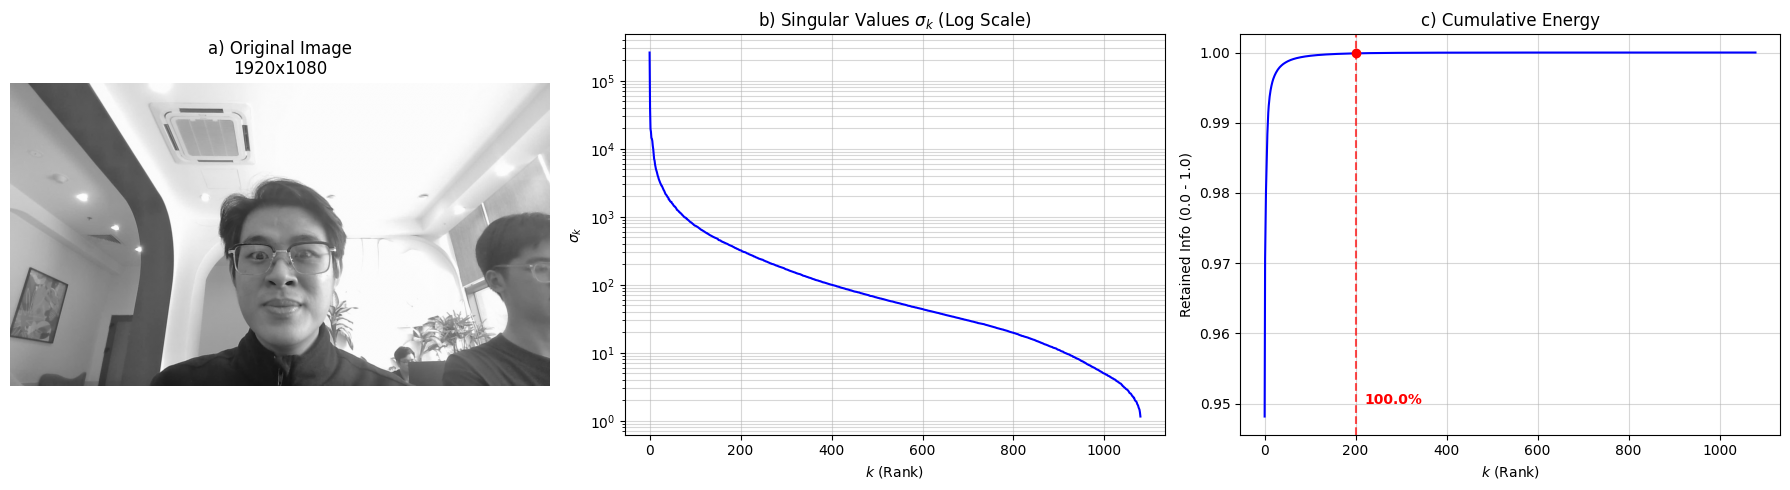

>>> 2. Kết quả nén ở các mức k=[5, 20, 50, 100]:


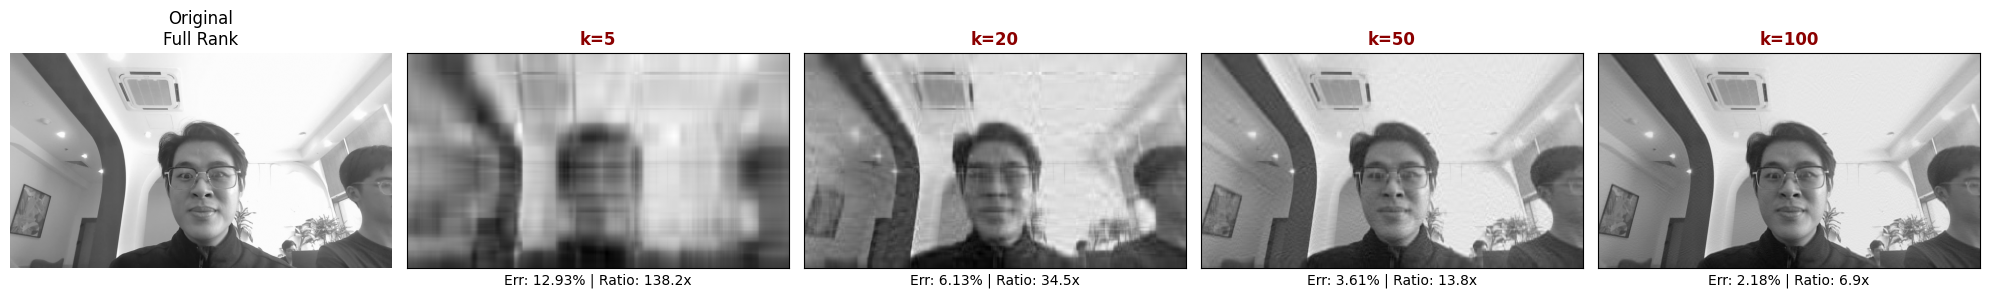


 BẢNG TỔNG HỢP KẾT QUẢ SVD 


,k (Rank),Error (%),Ratio,Info Retained
0,5,12.93,138.2x,87.07%
1,20,6.13,34.5x,93.87%
2,50,3.61,13.8x,96.39%
3,100,2.18,6.9x,97.82%


In [25]:
path = "./thuan.jpg"  # Đổi tên ảnh

# Bước 1: Tính toán
img_gray, U, S, Vt = process_svd(path)

if img_gray is not None:
    # Bước 2: Vẽ 3 biểu đồ phân tích
    print(">>> 1. Phân tích phổ năng lượng (SVD Spectrum):")
    plot_analysis_dashboard(img_gray, S)
    
    # Bước 3: Tái tạo và xem bảng số liệu
    # K đã chỉnh về mức hợp lý cho ảnh chân dung
    my_k = [5, 20, 50, 100] 
    print(f">>> 2. Kết quả nén ở các mức k={my_k}:")
    reconstruct_and_compare(img_gray, U, S, Vt, my_k)